# Task : Handling Imbalanced Data

## Machine Learning Internship – Neurofive Solutions

**Intern:** Amna Shahid

---

### Project Overview

Real-world datasets are often imbalanced, where one class appears much more frequently than another.

In this task, we use the Credit Card Fraud Detection dataset to:

- Explore class imbalance
- Visualize fraud vs non-fraud transactions
- Train a baseline model
- Handle imbalance using SMOTE
- Compare model performance before and after balancing

In [6]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

## Load Dataset

Let's load the Credit Card Fraud Detection dataset and inspect its contents.

In [7]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Information

Understanding the structure of the dataset.

In [8]:
# ============================================
# Dataset Information
# ============================================

print("Dataset Shape:", df.shape)

print("\nDataset Information\n")
df.info()

print("\nMissing Values\n")
print(df.isnull().sum())

Dataset Shape: (284807, 31)

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20

## Class Distribution

Let's check whether the dataset is balanced.

In [9]:
# ============================================
# Check Class Distribution
# ============================================

print(df["Class"].value_counts())

print("\nPercentage Distribution\n")

print(df["Class"].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## Visualize Class Imbalance

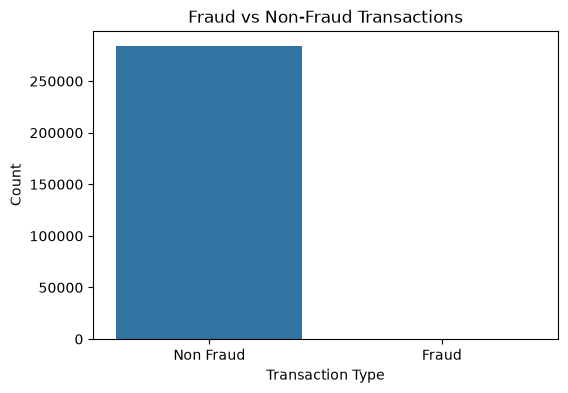

In [10]:
# ============================================
# Visualize Class Distribution
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.xlabel("Transaction Type")

plt.ylabel("Count")

plt.xticks([0,1],["Non Fraud","Fraud"])

plt.show()

## Prepare Features and Target Variable

In [11]:
# ============================================
# Separate Features and Target
# ============================================

X = df.drop("Class", axis=1)

y = df["Class"]

print(X.shape)

print(y.shape)

(284807, 30)
(284807,)


## Split Dataset

Separate the dataset into training and testing sets.

In [12]:
# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

(227845, 30)
(56962, 30)


# Baseline Logistic Regression Model

Train the model without handling class imbalance.

In [15]:
# ============================================
# Train Baseline Logistic Regression
# ============================================

baseline_model = LogisticRegression(max_iter=5000, random_state=42)
baseline_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Evaluate Baseline Model

In [14]:
# ============================================
# Predictions Before SMOTE
# ============================================

baseline_predictions = baseline_model.predict(X_test)

print(classification_report(y_test, baseline_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.70      0.77        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [16]:
# ============================================
# Save Baseline Metrics
# ============================================

baseline_precision = precision_score(y_test, baseline_predictions)

baseline_recall = recall_score(y_test, baseline_predictions)

baseline_f1 = f1_score(y_test, baseline_predictions)

print("Precision:", baseline_precision)

print("Recall:", baseline_recall)

print("F1 Score:", baseline_f1)

Precision: 0.8414634146341463
Recall: 0.7040816326530612
F1 Score: 0.7666666666666667


# Handle Class Imbalance using SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic examples of the minority class to balance the dataset.

In [17]:
# ============================================
# Apply SMOTE
# ============================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE")

print(y_train.value_counts())

print("\nAfter SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


## Train Logistic Regression After SMOTE

In [18]:
# ============================================
# Train Model on Balanced Dataset
# ============================================

smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_train_smote, y_train_smote)

C:\Users\User51023\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Evaluate Model After SMOTE

In [19]:
# ============================================
# Predictions After SMOTE
# ============================================

smote_predictions = smote_model.predict(X_test)

print(classification_report(y_test, smote_predictions))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [20]:
# ============================================
# Save SMOTE Metrics
# ============================================

smote_precision = precision_score(y_test, smote_predictions)

smote_recall = recall_score(y_test, smote_predictions)

smote_f1 = f1_score(y_test, smote_predictions)

print("Precision:", smote_precision)

print("Recall:", smote_recall)

print("F1 Score:", smote_f1)

Precision: 0.11780455153949129
Recall: 0.8979591836734694
F1 Score: 0.20828402366863905


# Compare Model Performance

In [21]:
# ============================================
# Performance Comparison
# ============================================

comparison = pd.DataFrame({
    "Metric":["Precision","Recall","F1 Score"],
    "Before SMOTE":[baseline_precision, baseline_recall, baseline_f1],
    "After SMOTE":[smote_precision, smote_recall, smote_f1]
})

comparison

,Metric,Before SMOTE,After SMOTE
0,Precision,0.841463,0.117805
1,Recall,0.704082,0.897959
2,F1 Score,0.766667,0.208284


# Visual Comparison

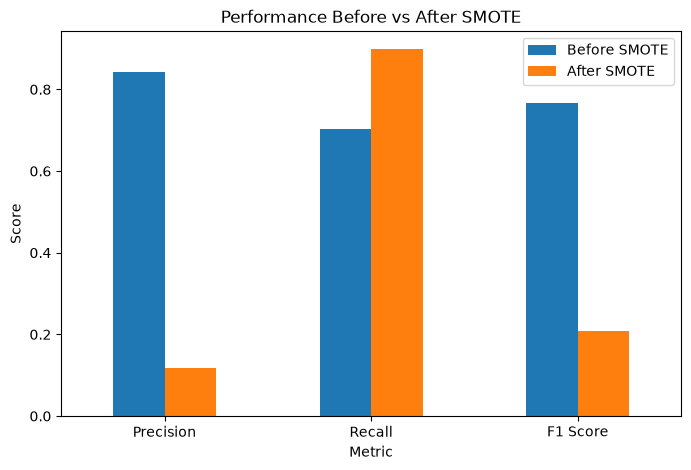

In [22]:
# ============================================
# Plot Comparison
# ============================================

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance Before vs After SMOTE")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

# Why Accuracy is Misleading

Although the baseline model may achieve very high accuracy, it can still fail to detect fraudulent transactions because fraud cases represent less than 1% of the data.

In highly imbalanced datasets, a model that predicts every transaction as "Non-Fraud" can still achieve excellent accuracy.

Therefore, Precision, Recall, and F1-score provide a much better evaluation of fraud detection performance.

For fraud detection, Recall is especially important because missing fraudulent transactions can result in significant financial losses.

# Project Conclusion

In this project, we explored a highly imbalanced credit card fraud dataset and observed that the majority of transactions were legitimate. A baseline Logistic Regression model was trained before addressing class imbalance. We then applied SMOTE to balance the training data and retrained the model. Comparing Precision, Recall, and F1-score before and after SMOTE demonstrated that balancing the data improved the model's ability to detect fraudulent transactions. This project highlights the importance of using appropriate evaluation metrics and handling class imbalance in real-world machine learning problems.